# Modelo de implementação própria 1

## Carregar DF

In [1]:
import pandas as pd
df = pd.read_csv('df_exportado.csv')

## Preparação do modelo

In [ ]:
import numpy as np
from collections import Counter
import sys
import os
sys.path.append(os.path.abspath("numpy_model"))
from numpy_model.neuralnet import NeuralNetwork
from numpy_model.layers import DenseLayer
from numpy_model.activation import ReLUActivation, SoftmaxActivation
from numpy_model.losses import CategoricalCrossEntropy
from numpy_model.metrics import accuracy
from numpy_model.data import Data
import itertools


# -----------------------------------------------------------------
# 1. PREPARAÇÃO DOS LABELS (Y_treino)
# -----------------------------------------------------------------
# Mapeamento para garantir a ordem dos pesos: [Human, OpenAI, Google, Meta, Anthropic]
label_map = {'Human': 0, 'OpenAI': 1, 'Google': 2, 'Meta': 3, 'Anthropic': 4}
y_indices = df['Label'].map(label_map).values

# Criar One-Hot Encoding (exigido pela CategoricalCrossEntropy)
num_classes = 5
Y_treino = np.eye(num_classes)[y_indices]

# -----------------------------------------------------------------
# 2. VETORIZAÇÃO DO TEXTO (X_treino) - Bag of Words Manual
# -----------------------------------------------------------------
STOPWORDS = set(['the', 'a', 'an', 'and', 'or', 'but', 'is', 'are', 'was', 'were', 'to', 'of', 'in', 'with', 'as', 'for', 'on', 'at', 'by', 'it', 'this', 'that', 'from', 'which'])
print("A criar vocabulário...")
todas_palavras = " ".join(df['Text']).lower().split()
todas_palavras = [palavra for palavra in todas_palavras if palavra not in STOPWORDS]

vocab = [palavra for palavra, count in Counter(todas_palavras).most_common(3000)]
word_to_idx = {palavra: i for i, palavra in enumerate(vocab)}

def vetorizar_texto(texto):
    vetor = np.zeros(len(vocab))
    for palavra in str(texto).lower().split():
        if palavra in word_to_idx:
            vetor[word_to_idx[palavra]] += 1

    soma = np.sum(vetor)
    if soma > 0:
        vetor = vetor / soma
    return vetor

print("A converter textos em vetores (X_treino)...")
X_treino = np.array([vetorizar_texto(t) for t in df['Text']])
print("X_treino criado com shape:", X_treino.shape)

A criar vocabulário...
A converter textos em vetores (X_treino)...


## Grid Search + k-fold

In [ ]:
# -----------------------------------------------------------------
# 3.0 CRIAR UMA AMOSTRA PEQUENA SÓ PARA O GRID SEARCH
# -----------------------------------------------------------------
tamanho_amostra = min(10000, len(X_treino))
indices_amostra = np.random.choice(len(X_treino), tamanho_amostra, replace=False)

X_grid = X_treino[indices_amostra]
Y_grid = Y_treino[indices_amostra]

print(f"A usar apenas {tamanho_amostra} textos para o Grid Search ser rápido...")

# -----------------------------------------------------------------
# 3.1 CONFIGURAR GRID SEARCH E K-FOLD MANUAL
# -----------------------------------------------------------------
pesos = [0.8, 0.9, 1.1, 1.1, 2.5] 
num_classes = 5

param_grid = {
    'learning_rate': [0.01, 0.005],
    'batch_size': [32, 64],
    'epochs': [10] 
}

keys, values = zip(*param_grid.items())
grid_configs = [dict(zip(keys, v)) for v in itertools.product(*values)]

k_folds = 3

# Usa a função kfold_split definida abaixo
def kfold_split(X, y, k=5, shuffle=True):
    indices = np.arange(len(X))
    if shuffle:
        np.random.shuffle(indices)
    fold_size = len(X) // k
    for i in range(k):
        start = i * fold_size
        end = (i + 1) * fold_size
        val_idx = indices[start:end]
        train_idx = np.concatenate((indices[:start], indices[end:]))
        yield train_idx, val_idx

melhor_acuracia = 0
melhores_params = None

print(f"A iniciar Grid Search com {len(grid_configs)} configurações ({k_folds}-Fold CV)...\n")

for config in grid_configs:
    print(f"-> A testar: {config}")
    fold_acuracias = []
    
    for fold, (train_idx, val_idx) in enumerate(kfold_split(X_grid, Y_grid, k=k_folds, shuffle=True)):
        X_train, X_val = X_grid[train_idx], X_grid[val_idx]
        Y_train, Y_val = Y_grid[train_idx], Y_grid[val_idx]
        
        dataset_treino = Data(X=X_train, y=Y_train)
        dataset_val = Data(X=X_val, y=Y_val)
        
        modelo = NeuralNetwork(
            epochs=config['epochs'], 
            batch_size=config['batch_size'], 
            learning_rate=config['learning_rate'],
            loss=CategoricalCrossEntropy(class_weights=pesos),
            metric=accuracy, 
            verbose=False 
        )
        
        modelo.add(DenseLayer(n_units=128, input_shape=(X_train.shape[1],)))
        modelo.add(ReLUActivation())
        modelo.add(DenseLayer(n_units=64))
        modelo.add(ReLUActivation())
        modelo.add(DenseLayer(n_units=num_classes))
        modelo.add(SoftmaxActivation())
        
        modelo.fit(dataset_treino)
        
        previsoes = modelo.predict(dataset_val)
        acc = np.mean(np.argmax(previsoes, axis=1) == np.argmax(Y_val, axis=1))
        fold_acuracias.append(acc)
        
    media_acuracia = np.mean(fold_acuracias)
    print(f"   [MÉDIA] Accuracy: {media_acuracia:.4f}\n")
    
    if media_acuracia > melhor_acuracia:
        melhor_acuracia = media_acuracia
        melhores_params = config

print(f"Melhores Parâmetros Encontrados: {melhores_params}")

## Treinar o Modelo

In [6]:
# -----------------------------------------------------------------
# 4. TREINAR O MODELO FINAL (COM TRAIN/VAL SPLIT)
# -----------------------------------------------------------------
from sklearn.model_selection import train_test_split

pesos = [0.8, 0.9, 1.1, 1.1, 2.5] 
tamanho_amostra_treino = min(30000, len(X_treino))
indices_amostra_treino = np.random.choice(len(X_treino), tamanho_amostra_treino, replace=False)
X_treino = X_treino[indices_amostra_treino]
Y_treino = Y_treino[indices_amostra_treino]

print("\nA separar 20% dos dados para validação (teste de overfitting)...")
# O 'stratify' garante que a percentagem de cada classe é mantida na divisão
X_train_final, X_val_final, Y_train_final, Y_val_final = train_test_split(
    X_treino, Y_treino, 
    test_size=0.2, 
    random_state=42, 
    stratify=np.argmax(Y_treino, axis=1)
)

print(f"Dados de Treino: {len(X_train_final)} textos")
print(f"Dados de Validação: {len(X_val_final)} textos")
print(f"\nA treinar o modelo FINAL ...\n")

modelo_final = NeuralNetwork(
    epochs=30,
    batch_size=32, 
    learning_rate=0.01,
    loss=CategoricalCrossEntropy(class_weights=pesos), # type: ignore
    metric=accuracy, 
    verbose=True
)

modelo_final.add(DenseLayer(n_units=128, input_shape=(X_train_final.shape[1],)))
modelo_final.add(ReLUActivation())
modelo_final.add(DenseLayer(n_units=64))
modelo_final.add(ReLUActivation())
modelo_final.add(DenseLayer(n_units=num_classes))
modelo_final.add(SoftmaxActivation())

# Treinar apenas nos 80% dos dados (Train)
dataset_treino_final = Data(X=X_train_final, y=Y_train_final)
modelo_final.fit(dataset_treino_final)

# -----------------------------------------------------------------
# 5. AVALIAR OVERFITTING E PERFORMANCE REAL
# -----------------------------------------------------------------
print("\n" + "="*40)
print("ANÁLISE DE OVERFITTING")
print("="*40)

# 1. Avaliar nos dados que o modelo já viu (Treino)
prev_treino = modelo_final.predict(dataset_treino_final)
acc_treino = np.mean(np.argmax(prev_treino, axis=1) == np.argmax(Y_train_final, axis=1))

# 2. Avaliar nos dados INVISÍVEIS (Validação)
dataset_val_final = Data(X=X_val_final, y=Y_val_final)
prev_val = modelo_final.predict(dataset_val_final)
acc_val = np.mean(np.argmax(prev_val, axis=1) == np.argmax(Y_val_final, axis=1))

print(f"Acurácia no Treino (Dados vistos)      : {acc_treino:.4f}")
print(f"Acurácia na Validação (Dados invisíveis): {acc_val:.4f}")

# Regra de polegar para Overfitting: se a diferença for > 5% (0.05)
diferenca = acc_treino - acc_val
print(f"Diferença (Queda de performance)        : {diferenca:.4f}")

if diferenca > 0.05:
    print("\nCUIDADO: O modelo apresenta sinais de Overfitting. Está a decorar os dados de treino.")
elif diferenca < -0.01:
    print("\nCurioso: O modelo está melhor na validação do que no treino (Underfitting ou dados de validação muito fáceis).")
else:
    print("\nEXCELENTE: O modelo está saudável e generalizou bem! Não há Overfitting significativo.")

print("\nTreino do Modelo Final Concluído!")



A separar 20% dos dados para validação (teste de overfitting)...
Dados de Treino: 24000 textos
Dados de Validação: 6000 textos

A treinar o modelo FINAL ...

Epoch 1/30 - loss: 1.4615 - accuracy: 0.4752
Epoch 2/30 - loss: 1.2541 - accuracy: 0.6093
Epoch 3/30 - loss: 1.1192 - accuracy: 0.6593
Epoch 4/30 - loss: 1.0260 - accuracy: 0.6884
Epoch 5/30 - loss: 0.9518 - accuracy: 0.7102
Epoch 6/30 - loss: 0.8900 - accuracy: 0.7320
Epoch 7/30 - loss: 0.8378 - accuracy: 0.7446
Epoch 8/30 - loss: 0.7938 - accuracy: 0.7558
Epoch 9/30 - loss: 0.7545 - accuracy: 0.7680
Epoch 10/30 - loss: 0.7193 - accuracy: 0.7780
Epoch 11/30 - loss: 0.6884 - accuracy: 0.7888
Epoch 12/30 - loss: 0.6614 - accuracy: 0.7937
Epoch 13/30 - loss: 0.6335 - accuracy: 0.7997
Epoch 14/30 - loss: 0.6091 - accuracy: 0.8099
Epoch 15/30 - loss: 0.5854 - accuracy: 0.8178
Epoch 16/30 - loss: 0.5658 - accuracy: 0.8225
Epoch 17/30 - loss: 0.5461 - accuracy: 0.8277
Epoch 18/30 - loss: 0.5280 - accuracy: 0.8326
Epoch 19/30 - loss: 0.

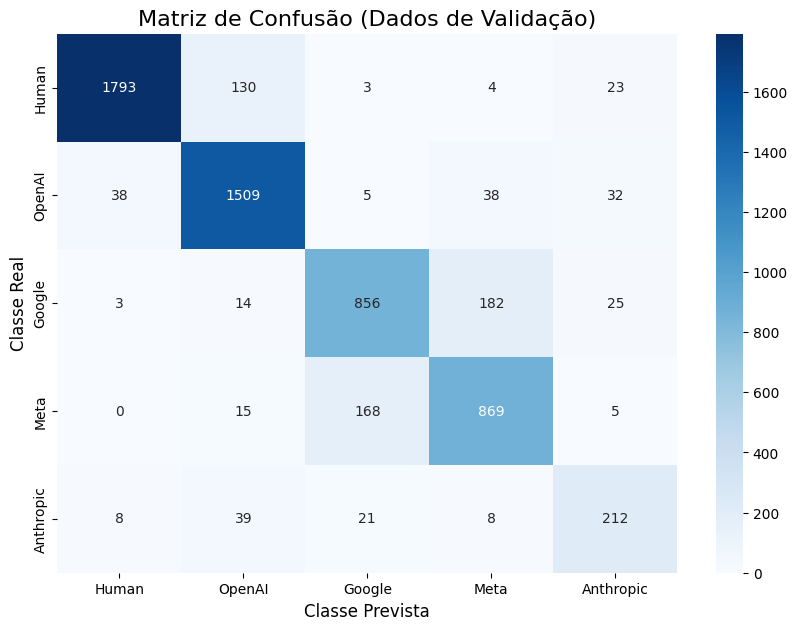

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

classes_previstas_val = np.argmax(prev_val, axis=1)
classes_reais_val = np.argmax(Y_val_final, axis=1)

nomes_classes = ['Human', 'OpenAI', 'Google', 'Meta', 'Anthropic']
cm = confusion_matrix(classes_reais_val, classes_previstas_val)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=nomes_classes, 
            yticklabels=nomes_classes)

plt.title('Matriz de Confusão (Dados de Validação)', fontsize=16)
plt.ylabel('Classe Real', fontsize=12)
plt.xlabel('Classe Prevista', fontsize=12)
plt.show()

## Exportar o Modelo

In [8]:
import pickle

# 1. Guardar o vocabulário
with open('vocab_numpy.pkl', 'wb') as f:
    pickle.dump(vocab, f)

# 2. Guardar o modelo treinado
with open('modelo_numpy_final.pkl', 'wb') as f:
    pickle.dump(modelo_final, f)

print("Modelo e vocabulário guardados com sucesso para a submissão!")

Modelo e vocabulário guardados com sucesso para a submissão!
